# 08 — Multi-year year-on-year PLR

This notebook estimates module-level performance loss rates using the multi-year year-on-year method.

The method is applied to daily \(PR_\mathrm{DC,25C}\) time series. Unlike a standard one-year YoY implementation, this notebook constructs valid same-period pairs across multiple year separations. Each daily observation can be paired with observations approximately 1, 2, 3, or 4 years later, provided the matched date falls within the allowed calendar tolerance.

The main outputs are:

1. pair-level annualised multi-year YoY PLR values
2. module-level median multi-year YoY PLR estimates
3. bootstrap confidence intervals for the module-level median
4. a main g200 module-level PLR figure
5. appendix uncertainty diagnostics
6. an optional irradiance-filter sensitivity figure

## 1. Imports and plotting style

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 11,
    "legend.title_fontsize": 11,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 12
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 11

## 2. Paths

In [2]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data_processed"
PLR_INPUT_DIR = DATA_PROCESSED_DIR / "plr_final_inputs"
YOY_OUTPUT_DIR = DATA_PROCESSED_DIR / "yoy_outputs"

FINAL_FIG_DIR = PROJECT_ROOT / "figures" / "final figures"
FINAL_TABLE_DIR = PROJECT_ROOT / "tables" / "final tables"

for folder in [YOY_OUTPUT_DIR, FINAL_FIG_DIR, FINAL_TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DAILY_INPUT_PATHS = {
    "g200": PLR_INPUT_DIR / "g200_daily_pr25c_filtered_for_plr.parquet",
    "g400": PLR_INPUT_DIR / "g400_daily_pr25c_filtered_for_plr.parquet",
    "sunny": PLR_INPUT_DIR / "sunny_daily_pr25c_filtered_for_plr.parquet",
}

print("Project root:", PROJECT_ROOT)
print("PLR input folder:", PLR_INPUT_DIR)
print("YoY output folder:", YOY_OUTPUT_DIR)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)

for dataset_name, path in DAILY_INPUT_PATHS.items():
    print(f"{dataset_name} input exists:", path.exists(), "|", path)

Project root: C:\Users\amina\Thesis\Final Pipeline
PLR input folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs
YoY output folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\yoy_outputs
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables
g200 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g200_daily_pr25c_filtered_for_plr.parquet
g400 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g400_daily_pr25c_filtered_for_plr.parquet
sunny input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\sunny_daily_pr25c_filtered_for_plr.parquet


## 3. Constants and module metadata

The multi-year YoY method uses daily \(PR_\mathrm{DC,25C}\) values. For each module, valid pairs are constructed across 1, 2, 3, and 4 year separations, using a ±15 day matching tolerance.

The module-level PLR estimate is the median of all valid pair-level annualised PLR values.

In [3]:
MAIN_METRIC = "PR_25C"
DATE_COL = "Date"

MULTI_YEAR_TARGETS = [1, 2, 3, 4]
MATCH_TOLERANCE_DAYS = 15

DAYS_PER_YEAR = 365.25
MIN_YOY_PAIRS = 30

N_BOOT = 1000
BOOT_RANDOM_SEED = 42
CONFIDENCE_LEVEL = 0.95

BLACK = "#222222"

DATASET_LABELS = {
    "g200": r"$G_\mathrm{POA} \geq 200$ W/m$^2$",
    "g400": r"$G_\mathrm{POA} \geq 400$ W/m$^2$",
    "sunny": "Sunny-day",
}

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
}

DATASET_COLORS = {
    "g200": "#8E44AD",
    "g400": "#C44569",
    "sunny": "#4A4E69",
}

module_meta = pd.DataFrame({
    "Module_ID": list(range(1, 11)),
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
})

MODULE_TYPE_MAP = dict(zip(module_meta["Module_ID"], module_meta["Type"]))

display(module_meta)

,Module_ID,Type
0,1,PID/Reference
1,2,Reference
2,3,uCrack
3,4,uCrack
4,5,Reference
5,6,uCrack
6,7,uCrack
7,8,uCrack
8,9,uCrack
9,10,Reference


## 4. Helper functions

In [5]:
def save_fig(filename, fig=None):
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def normalise_type_label(value):
    if pd.isna(value):
        return "Unknown"

    value_str = str(value).strip()

    if value_str in TYPE_COLORS:
        return value_str

    value_low = value_str.lower()

    if "pid" in value_low:
        return "PID/Reference"
    if "ucrack" in value_low or "microcrack" in value_low or "crack" in value_low:
        return "uCrack"
    if "ref" in value_low:
        return "Reference"

    return "Unknown"


def module_category_legend_handles():
    return [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="Reference",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["uCrack"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="uCrack",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["PID/Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="PID/Reference",
        ),
    ]

## 5. Load daily PLR input datasets

The multi-year YoY method is applied to daily \(PR_\mathrm{DC,25C}\). The g200 dataset is treated as the main dataset, while g400 and sunny are retained for irradiance-filter sensitivity analysis.

In [6]:
daily_datasets = {}

for dataset_name, path in DAILY_INPUT_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing daily input for {dataset_name}: {path}")

    df = pd.read_parquet(path)

    if DATE_COL not in df.columns:
        raise ValueError(f"{dataset_name}: missing required date column `{DATE_COL}`.")

    df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.tz_localize(None)

    if "Type" not in df.columns:
        df = df.merge(module_meta, on="Module_ID", how="left")

    df["Type"] = df["Type"].apply(normalise_type_label)

    df["Year"] = df[DATE_COL].dt.year
    df["Month"] = df[DATE_COL].dt.month
    df["DayOfYear"] = df[DATE_COL].dt.dayofyear

    df["dataset"] = dataset_name
    df["dataset_label"] = DATASET_LABELS[dataset_name]

    df = df.sort_values(["Module_ID", DATE_COL]).reset_index(drop=True)

    required_cols = ["Module_ID", "Type", DATE_COL, MAIN_METRIC]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"{dataset_name}: missing required columns: {missing_cols}")

    daily_datasets[dataset_name] = df

    print(f"{dataset_name} loaded")
    print("Shape:", df.shape)
    print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())
    print("Modules:", sorted(df["Module_ID"].unique()))
    print("-" * 80)

g200 loaded
Shape: (9561, 39)
Date range: 2017-01-02 00:00:00 to 2021-12-27 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
g400 loaded
Shape: (7949, 39)
Date range: 2017-01-02 00:00:00 to 2021-12-27 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
sunny loaded
Shape: (4041, 39)
Date range: 2017-01-02 00:00:00 to 2021-12-27 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------


## 6. Summarise daily inputs

This compact summary checks the number of daily values available for each irradiance-filtered input.

In [7]:
daily_input_summary = []

for dataset_name, df in daily_datasets.items():
    daily_input_summary.append({
        "Dataset": dataset_name,
        "Input definition": DATASET_LABELS[dataset_name],
        "Daily records": len(df),
        "Modules": df["Module_ID"].nunique(),
        "First date": df[DATE_COL].min(),
        "Last date": df[DATE_COL].max(),
        "Median PR_DC,25C": df[MAIN_METRIC].median(),
        "Minimum PR_DC,25C": df[MAIN_METRIC].min(),
        "Maximum PR_DC,25C": df[MAIN_METRIC].max(),
    })

daily_input_summary = pd.DataFrame(daily_input_summary)

display(daily_input_summary)

daily_input_summary.to_csv(
    FINAL_TABLE_DIR / "multi_year_yoy_daily_input_summary.csv",
    index=False,
)

,Dataset,Input definition,Daily records,Modules,First date,Last date,"Median PR_DC,25C","Minimum PR_DC,25C","Maximum PR_DC,25C"
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,9561,10,2017-01-02,2021-12-27,0.944826,0.622181,1.033916
1,g400,$G_\mathrm{POA} \geq 400$ W/m$^2$,7949,10,2017-01-02,2021-12-27,0.954437,0.631819,1.047898
2,sunny,Sunny-day,4041,10,2017-01-02,2021-12-27,0.946842,0.631558,1.023978


## 7. Construct multi-year YoY pairs

This is the main multi-year YoY implementation.

For each module, every valid daily \(PR_\mathrm{DC,25C}\) observation is considered as a start point. The code then searches for the nearest valid observation approximately 1, 2, 3, and 4 years later. A match is accepted when it falls within ±15 days of the target date.

Each valid pair is annualised using its exact time separation:

\[
PLR_\mathrm{YoY,pair} =
100 \times
\frac{PR_{\mathrm{DC,25C},2} - PR_{\mathrm{DC,25C},1}}
{PR_{\mathrm{DC,25C},1}}
\times
\frac{1}{\Delta t_\mathrm{years}}
\]

Negative values indicate performance loss.

In [8]:
def construct_multi_year_yoy_pairs_for_module(module_df):
    """
    Construct multi-year YoY pairs for one module.
    """
    module_df = module_df.sort_values(DATE_COL).copy()

    module_id = int(module_df["Module_ID"].iloc[0])
    module_type = module_df["Type"].iloc[0]
    dataset_name = module_df["dataset"].iloc[0]
    dataset_label = module_df["dataset_label"].iloc[0]

    lookup = (
        module_df[[DATE_COL, MAIN_METRIC]]
        .dropna(subset=[DATE_COL, MAIN_METRIC])
        .rename(columns={
            DATE_COL: "date_end",
            MAIN_METRIC: "PR_25C_end",
        })
        .copy()
    )

    start_df = (
        module_df[[DATE_COL, MAIN_METRIC]]
        .dropna(subset=[DATE_COL, MAIN_METRIC])
        .rename(columns={
            DATE_COL: "date_start",
            MAIN_METRIC: "PR_25C_start",
        })
        .copy()
    )

    pair_rows = []

    for _, row in start_df.iterrows():
        date_start = row["date_start"]
        pr_start = row["PR_25C_start"]

        if pd.isna(pr_start) or pr_start <= 0:
            continue

        for target_years in MULTI_YEAR_TARGETS:
            target_date = date_start + pd.DateOffset(years=target_years)

            window_start = target_date - pd.Timedelta(days=MATCH_TOLERANCE_DAYS)
            window_end = target_date + pd.Timedelta(days=MATCH_TOLERANCE_DAYS)

            candidates = lookup.loc[
                (lookup["date_end"] >= window_start)
                & (lookup["date_end"] <= window_end)
            ].copy()

            if candidates.empty:
                continue

            candidates["abs_match_error_days"] = (
                candidates["date_end"] - target_date
            ).abs().dt.days

            best_match = (
                candidates
                .sort_values(["abs_match_error_days", "date_end"])
                .iloc[0]
            )

            date_end = best_match["date_end"]
            pr_end = best_match["PR_25C_end"]

            if pd.isna(pr_end) or pr_end <= 0:
                continue

            delta_days = (date_end - date_start).days
            delta_years = delta_days / DAYS_PER_YEAR

            if delta_years <= 0:
                continue

            relative_change = (pr_end - pr_start) / pr_start
            pair_plr = 100 * relative_change / delta_years

            pair_rows.append({
                "dataset": dataset_name,
                "dataset_label": dataset_label,
                "Module_ID": module_id,
                "Type": module_type,
                "date_start": date_start,
                "date_end": date_end,
                "target_years": target_years,
                "target_date": target_date,
                "delta_days": delta_days,
                "delta_years": delta_years,
                "match_error_days": (date_end - target_date).days,
                "abs_match_error_days": abs((date_end - target_date).days),
                "PR_25C_start": pr_start,
                "PR_25C_end": pr_end,
                "relative_change": relative_change,
                "PLR_YoY_pair_pct_per_year": pair_plr,
            })

    return pd.DataFrame(pair_rows)

In [9]:
pair_tables = []

for dataset_name, df in daily_datasets.items():
    for module_id, module_df in df.groupby("Module_ID"):
        pair_df = construct_multi_year_yoy_pairs_for_module(module_df)

        if not pair_df.empty:
            pair_tables.append(pair_df)

yoy_pairs = (
    pd.concat(pair_tables, ignore_index=True)
    .sort_values(["dataset", "Module_ID", "date_start", "target_years"])
    .reset_index(drop=True)
)

print("Multi-year YoY pairs constructed.")
print("Shape:", yoy_pairs.shape)

display(yoy_pairs.head())

Multi-year YoY pairs constructed.
Shape: (40070, 16)


,dataset,dataset_label,Module_ID,Type,date_start,date_end,target_years,target_date,delta_days,delta_years,match_error_days,abs_match_error_days,PR_25C_start,PR_25C_end,relative_change,PLR_YoY_pair_pct_per_year
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,2017-01-02,2018-01-02,1,2018-01-02,365,0.999316,0,0,1.003344,1.002640,-0.000702,-0.070247
1,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,2017-01-02,2019-01-02,2,2019-01-02,730,1.998631,0,0,1.003344,0.993908,-0.009404,-0.470533
2,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,2017-01-02,2020-01-04,3,2020-01-02,1097,3.003422,2,2,1.003344,1.022300,0.018893,0.629044
3,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,2017-01-02,2021-01-09,4,2021-01-02,1468,4.019165,7,7,1.003344,1.012777,0.009402,0.233923
4,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,2017-01-05,2018-01-07,1,2018-01-05,367,1.004791,2,2,0.976879,0.982127,0.005373,0.534723


## 8. Check YoY pair support

A minimum number of valid multi-year YoY pairs is required before estimating a module-level PLR.

In [10]:
yoy_pair_summary = (
    yoy_pairs
    .groupby(["dataset", "dataset_label", "Module_ID", "Type"], as_index=False)
    .agg(
        n_yoy_pairs=("PLR_YoY_pair_pct_per_year", "size"),
        first_pair_start=("date_start", "min"),
        last_pair_start=("date_start", "max"),
        median_delta_days=("delta_days", "median"),
        min_delta_days=("delta_days", "min"),
        max_delta_days=("delta_days", "max"),
        median_abs_match_error_days=("abs_match_error_days", "median"),
        max_abs_match_error_days=("abs_match_error_days", "max"),
        median_pair_plr_pct_per_year=("PLR_YoY_pair_pct_per_year", "median"),
        q05_pair_plr_pct_per_year=("PLR_YoY_pair_pct_per_year", lambda x: x.quantile(0.05)),
        q95_pair_plr_pct_per_year=("PLR_YoY_pair_pct_per_year", lambda x: x.quantile(0.95)),
    )
)

yoy_pair_summary["passes_min_yoy_pairs"] = (
    yoy_pair_summary["n_yoy_pairs"] >= MIN_YOY_PAIRS
)

display(yoy_pair_summary)

if not yoy_pair_summary["passes_min_yoy_pairs"].all():
    failing = yoy_pair_summary.loc[~yoy_pair_summary["passes_min_yoy_pairs"]]
    display(failing)
    raise ValueError("Some module-dataset combinations do not meet the minimum YoY pair requirement.")

print("All module-dataset combinations pass the minimum YoY pair requirement.")

,dataset,dataset_label,Module_ID,Type,n_yoy_pairs,first_pair_start,last_pair_start,median_delta_days,min_delta_days,max_delta_days,median_abs_match_error_days,max_abs_match_error_days,median_pair_plr_pct_per_year,q05_pair_plr_pct_per_year,q95_pair_plr_pct_per_year,passes_min_yoy_pairs
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,1806,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.333248,-3.159270,2.550117,True
1,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,2,Reference,1817,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.359134,-3.261025,2.513274,True
2,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,3,uCrack,1801,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,0.039615,-5.067020,4.716985,True
3,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,4,uCrack,1790,2017-01-02,2021-01-04,730.0,350,1474,0.0,15,-0.459581,-3.246936,2.472717,True
4,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,5,Reference,1799,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.399898,-3.174532,2.747161,True
5,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,6,uCrack,1814,2017-01-02,2021-01-04,730.0,350,1474,0.0,15,-0.408718,-3.312734,2.773412,True
6,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,7,uCrack,1823,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.630290,-4.187174,3.086846,True
7,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,8,uCrack,1803,2017-01-02,2020-12-25,730.0,351,1476,0.0,15,-0.938799,-4.624909,2.784675,True
8,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,9,uCrack,1778,2017-01-02,2020-10-13,730.0,351,1474,0.0,15,-1.494343,-6.181814,2.386502,True
9,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,10,Reference,1699,2017-01-02,2020-10-14,730.0,350,1474,0.0,15,-1.272990,-6.374579,2.811740,True


All module-dataset combinations pass the minimum YoY pair requirement.


## 9. Estimate module-level multi-year YoY PLR

The module-level multi-year YoY PLR is calculated as the median of all valid pair-level annualised PLR values for that module.

The median is used because the pair-level distribution can contain residual variability from missing data, shading, soiling, or other field effects.

In [11]:
def bootstrap_median_ci(values, n_boot=N_BOOT, random_seed=BOOT_RANDOM_SEED):
    """
    Bootstrap the median of pair-level YoY PLR values.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {
            "median": np.nan,
            "bootstrap_se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "bootstrap_distribution": np.array([]),
        }

    rng = np.random.default_rng(random_seed)
    boot_medians = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_medians[i] = np.median(sample)

    alpha = 1 - CONFIDENCE_LEVEL

    return {
        "median": np.median(values),
        "bootstrap_se": np.std(boot_medians, ddof=1),
        "ci_low": np.quantile(boot_medians, alpha / 2),
        "ci_high": np.quantile(boot_medians, 1 - alpha / 2),
        "bootstrap_distribution": boot_medians,
    }

In [12]:
dataset_order = ["g200", "g400", "sunny"]

result_rows = []
bootstrap_tables = []

for (dataset_name, module_id), pair_df in yoy_pairs.groupby(["dataset", "Module_ID"]):
    pair_df = pair_df.copy()

    module_type = pair_df["Type"].iloc[0]
    dataset_label = pair_df["dataset_label"].iloc[0]

    values = pair_df["PLR_YoY_pair_pct_per_year"].to_numpy()

    boot_seed = (
        BOOT_RANDOM_SEED
        + int(module_id)
        + 1000 * dataset_order.index(dataset_name)
    )

    boot = bootstrap_median_ci(
        values,
        n_boot=N_BOOT,
        random_seed=boot_seed,
    )

    result_rows.append({
        "dataset": dataset_name,
        "dataset_label": dataset_label,
        "Module_ID": int(module_id),
        "Type": module_type,
        "n_yoy_pairs": len(values),

        "first_pair_start": pair_df["date_start"].min(),
        "last_pair_start": pair_df["date_start"].max(),

        "median_delta_days": pair_df["delta_days"].median(),
        "min_delta_days": pair_df["delta_days"].min(),
        "max_delta_days": pair_df["delta_days"].max(),

        "median_abs_match_error_days": pair_df["abs_match_error_days"].median(),
        "max_abs_match_error_days": pair_df["abs_match_error_days"].max(),

        "PLR_YoY_pct_per_year": boot["median"],
        "PLR_YoY_bootstrap_se_pct_per_year": boot["bootstrap_se"],
        "PLR_YoY_ci_low_pct_per_year": boot["ci_low"],
        "PLR_YoY_ci_high_pct_per_year": boot["ci_high"],

        "pair_plr_mean_pct_per_year": np.mean(values),
        "pair_plr_std_pct_per_year": np.std(values, ddof=1),
        "pair_plr_q05_pct_per_year": np.quantile(values, 0.05),
        "pair_plr_q95_pct_per_year": np.quantile(values, 0.95),
    })

    boot_df = pd.DataFrame({
        "dataset": dataset_name,
        "dataset_label": dataset_label,
        "Module_ID": int(module_id),
        "Type": module_type,
        "bootstrap_iteration": np.arange(1, N_BOOT + 1),
        "PLR_YoY_bootstrap_median_pct_per_year": boot["bootstrap_distribution"],
    })

    bootstrap_tables.append(boot_df)

yoy_results = (
    pd.DataFrame(result_rows)
    .sort_values(["dataset", "Module_ID"])
    .reset_index(drop=True)
)

yoy_bootstrap_distribution = (
    pd.concat(bootstrap_tables, ignore_index=True)
    .sort_values(["dataset", "Module_ID", "bootstrap_iteration"])
    .reset_index(drop=True)
)

yoy_g200_results = (
    yoy_results
    .loc[yoy_results["dataset"] == "g200"]
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

display(yoy_g200_results)

,dataset,dataset_label,Module_ID,Type,n_yoy_pairs,first_pair_start,last_pair_start,median_delta_days,min_delta_days,max_delta_days,median_abs_match_error_days,max_abs_match_error_days,PLR_YoY_pct_per_year,PLR_YoY_bootstrap_se_pct_per_year,PLR_YoY_ci_low_pct_per_year,PLR_YoY_ci_high_pct_per_year,pair_plr_mean_pct_per_year,pair_plr_std_pct_per_year,pair_plr_q05_pct_per_year,pair_plr_q95_pct_per_year
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,1806,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.333248,0.033144,-0.412784,-0.280843,-0.298118,1.713960,-3.159270,2.550117
1,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,2,Reference,1817,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.359134,0.027232,-0.415543,-0.303774,-0.387322,1.738836,-3.261025,2.513274
2,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,3,uCrack,1801,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,0.039615,0.056188,-0.074407,0.157695,0.006549,2.967654,-5.067020,4.716985
3,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,4,uCrack,1790,2017-01-02,2021-01-04,730.0,350,1474,0.0,15,-0.459581,0.026908,-0.515255,-0.402082,-0.457154,1.766380,-3.246936,2.472717
4,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,5,Reference,1799,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.399898,0.037225,-0.460966,-0.326111,-0.337906,1.801549,-3.174532,2.747161
5,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,6,uCrack,1814,2017-01-02,2021-01-04,730.0,350,1474,0.0,15,-0.408718,0.039644,-0.489833,-0.336991,-0.377518,1.842727,-3.312734,2.773412
6,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,7,uCrack,1823,2017-01-02,2021-01-09,730.0,351,1474,0.0,15,-0.630290,0.043596,-0.695755,-0.537820,-0.606810,2.187194,-4.187174,3.086846
7,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,8,uCrack,1803,2017-01-02,2020-12-25,730.0,351,1476,0.0,15,-0.938799,0.045613,-1.021009,-0.852375,-0.977784,2.320136,-4.624909,2.784675
8,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,9,uCrack,1778,2017-01-02,2020-10-13,730.0,351,1474,0.0,15,-1.494343,0.051164,-1.613248,-1.413312,-1.678088,2.595805,-6.181814,2.386502
9,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,10,Reference,1699,2017-01-02,2020-10-14,730.0,350,1474,0.0,15,-1.272990,0.052690,-1.374344,-1.166623,-1.421648,2.837287,-6.374579,2.811740


## 10. Save YoY outputs

The module-level results, pair-level values, and bootstrap distributions are saved for downstream ensemble and sensitivity analysis.

In [13]:
YOY_RESULTS_PATH = FINAL_TABLE_DIR / "multi_year_yoy_plr_estimates_all_datasets.csv"
YOY_G200_RESULTS_PATH = FINAL_TABLE_DIR / "multi_year_yoy_plr_estimates_g200.csv"
YOY_PAIR_VALUES_PATH = YOY_OUTPUT_DIR / "multi_year_yoy_pair_values_all_datasets.parquet"
YOY_BOOTSTRAP_PATH = YOY_OUTPUT_DIR / "multi_year_yoy_bootstrap_distributions_all_datasets.parquet"

yoy_results.to_csv(YOY_RESULTS_PATH, index=False)
yoy_g200_results.to_csv(YOY_G200_RESULTS_PATH, index=False)
yoy_pairs.to_parquet(YOY_PAIR_VALUES_PATH, index=False)
yoy_bootstrap_distribution.to_parquet(YOY_BOOTSTRAP_PATH, index=False)

print("Saved YoY results:", YOY_RESULTS_PATH)
print("Saved g200 YoY results:", YOY_G200_RESULTS_PATH)
print("Saved pair-level values:", YOY_PAIR_VALUES_PATH)
print("Saved bootstrap distributions:", YOY_BOOTSTRAP_PATH)

Saved YoY results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\multi_year_yoy_plr_estimates_all_datasets.csv
Saved g200 YoY results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\multi_year_yoy_plr_estimates_g200.csv
Saved pair-level values: C:\Users\amina\Thesis\Final Pipeline\data_processed\yoy_outputs\multi_year_yoy_pair_values_all_datasets.parquet
Saved bootstrap distributions: C:\Users\amina\Thesis\Final Pipeline\data_processed\yoy_outputs\multi_year_yoy_bootstrap_distributions_all_datasets.parquet


## 11. Plot module-level multi-year YoY PLR estimates

This is the main multi-year YoY results figure. Error bars represent 95% bootstrap confidence intervals.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\multi_year_yoy_module_level_plr_estimates_g200.png


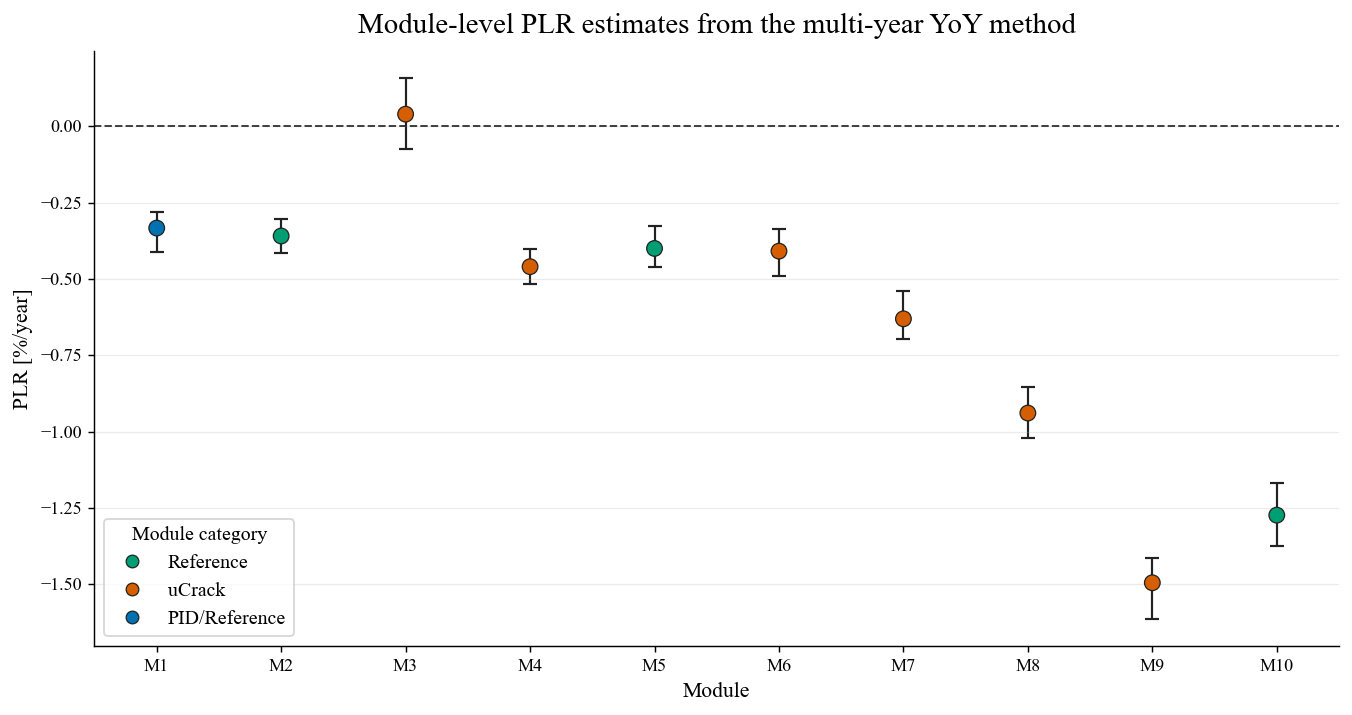

In [14]:
def plot_multi_year_yoy_module_level_plr(
    yoy_g200_results,
    save_name="multi_year_yoy_module_level_plr_estimates_g200.png",
):
    plot_df = yoy_g200_results.sort_values("Module_ID").copy()

    x = plot_df["Module_ID"].astype(int).to_numpy()
    y = plot_df["PLR_YoY_pct_per_year"].to_numpy()

    yerr_lower = y - plot_df["PLR_YoY_ci_low_pct_per_year"].to_numpy()
    yerr_upper = plot_df["PLR_YoY_ci_high_pct_per_year"].to_numpy() - y

    colors = plot_df["Type"].map(TYPE_COLORS).to_list()

    fig, ax = plt.subplots(figsize=(10.5, 5.6))

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor=BLACK,
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=1,
    )

    ax.scatter(
        x,
        y,
        s=75,
        c=colors,
        edgecolor=BLACK,
        linewidth=0.7,
        zorder=2,
    )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f"M{i}" for i in range(1, 11)])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Module-level PLR estimates from the multi-year YoY method",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=module_category_legend_handles(),
        title="Module category",
        loc="lower left",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    save_fig(save_name, fig)
    plt.show()


plot_multi_year_yoy_module_level_plr(yoy_g200_results)

## 12. Plot pair-level multi-year YoY distributions

This figure shows the distribution of annualised pair-level multi-year YoY PLR values for selected modules. The black diamond marks the module-level median used as the YoY PLR estimate.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_multi_year_yoy_pair_level_distributions_selected_modules.png


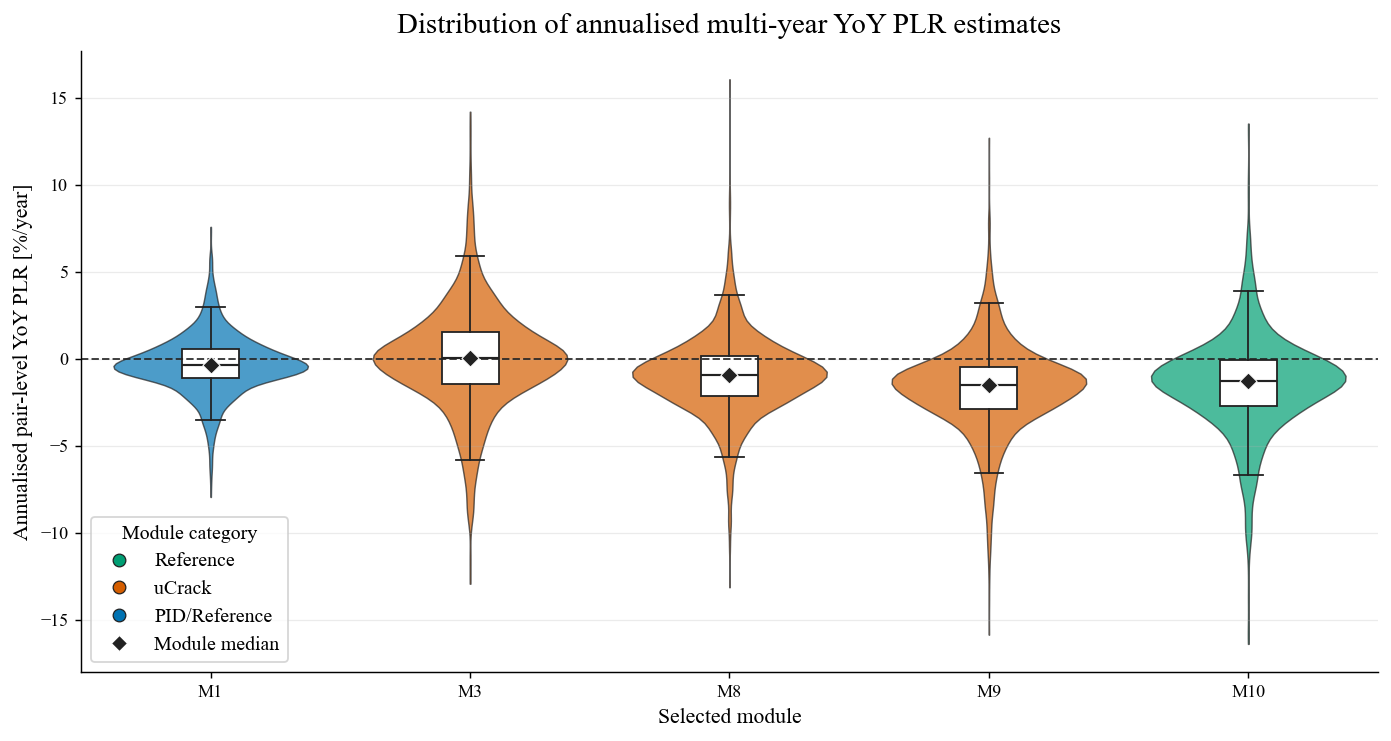

In [15]:
def plot_selected_pair_level_distributions(
    yoy_pairs,
    yoy_results,
    selected_modules=[1, 3, 8, 9, 10],
    dataset_name="g200",
    save_name="appendix_multi_year_yoy_pair_level_distributions_selected_modules.png",
):
    plot_pairs = yoy_pairs.loc[
        (yoy_pairs["dataset"] == dataset_name)
        & (yoy_pairs["Module_ID"].isin(selected_modules))
    ].copy()

    plot_results = yoy_results.loc[
        (yoy_results["dataset"] == dataset_name)
        & (yoy_results["Module_ID"].isin(selected_modules))
    ].copy()

    positions = np.arange(1, len(selected_modules) + 1)

    data_by_module = [
        plot_pairs.loc[
            plot_pairs["Module_ID"] == module_id,
            "PLR_YoY_pair_pct_per_year",
        ].dropna().to_numpy()
        for module_id in selected_modules
    ]

    fig, ax = plt.subplots(figsize=(10.8, 5.8))

    violin = ax.violinplot(
        data_by_module,
        positions=positions,
        widths=0.75,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, module_id in zip(violin["bodies"], selected_modules):
        module_type = MODULE_TYPE_MAP[module_id]
        body.set_facecolor(TYPE_COLORS[module_type])
        body.set_edgecolor(BLACK)
        body.set_alpha(0.70)
        body.set_linewidth(0.8)

    box = ax.boxplot(
        data_by_module,
        positions=positions,
        widths=0.22,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": BLACK, "linewidth": 1.2},
        boxprops={"facecolor": "white", "edgecolor": BLACK, "linewidth": 1.0},
        whiskerprops={"color": BLACK, "linewidth": 1.0},
        capprops={"color": BLACK, "linewidth": 1.0},
    )

    for module_id, pos in zip(selected_modules, positions):
        median_value = plot_results.loc[
            plot_results["Module_ID"] == module_id,
            "PLR_YoY_pct_per_year",
        ].iloc[0]

        ax.scatter(
            pos,
            median_value,
            marker="D",
            s=45,
            color=BLACK,
            edgecolor="white",
            linewidth=0.6,
            zorder=5,
        )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xticks(positions)
    ax.set_xticklabels([f"M{m}" for m in selected_modules])

    ax.set_xlabel("Selected module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Annualised pair-level YoY PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Distribution of annualised multi-year YoY PLR estimates",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    median_handle = Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        color=BLACK,
        markeredgecolor="white",
        markeredgewidth=0.6,
        markersize=6,
        label="Module median",
    )

    ax.legend(
        handles=module_category_legend_handles() + [median_handle],
        title="Module category",
        loc="lower left",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    save_fig(save_name, fig)
    plt.show()


plot_selected_pair_level_distributions(yoy_pairs, yoy_results)

## 13. Plot bootstrap distributions

This appendix figure shows the bootstrap distributions of the median multi-year YoY PLR estimate for selected modules. The solid vertical line marks the median estimate and the dashed lines mark the 95% bootstrap confidence interval.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_multi_year_yoy_bootstrap_distributions_selected_modules.png


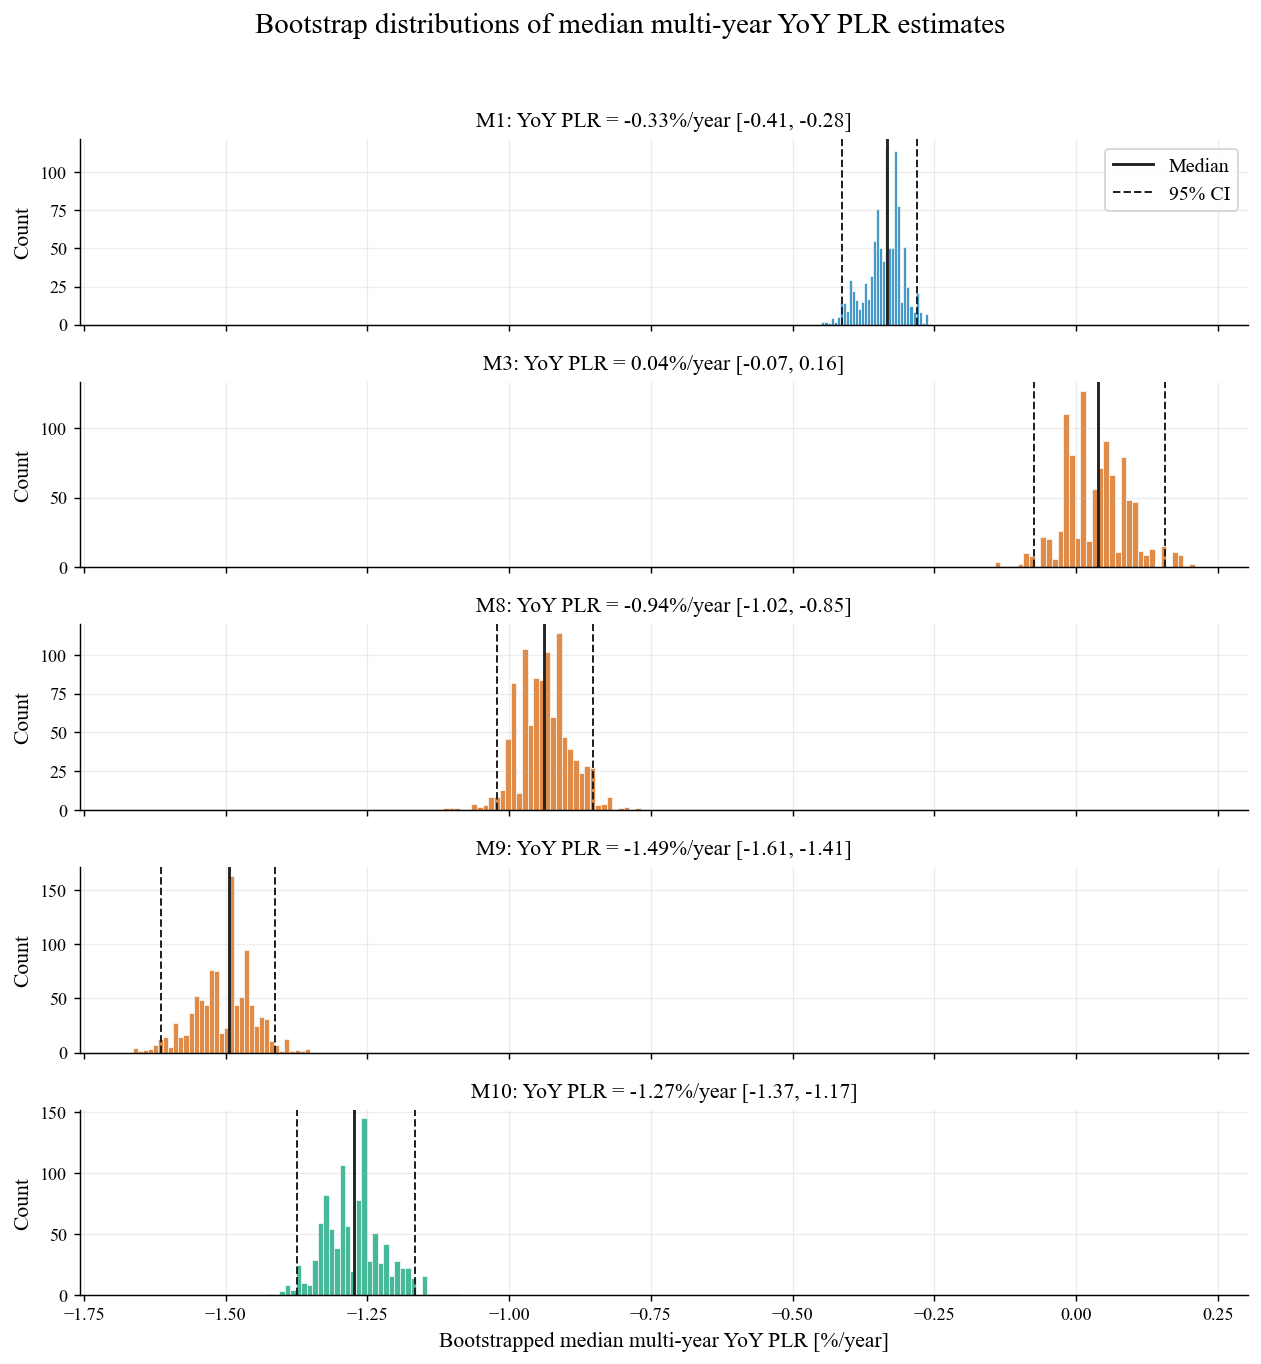

In [16]:
def plot_selected_bootstrap_distributions(
    yoy_bootstrap_distribution,
    yoy_results,
    selected_modules=[1, 3, 8, 9, 10],
    dataset_name="g200",
    save_name="appendix_multi_year_yoy_bootstrap_distributions_selected_modules.png",
):
    boot_plot = yoy_bootstrap_distribution.loc[
        (yoy_bootstrap_distribution["dataset"] == dataset_name)
        & (yoy_bootstrap_distribution["Module_ID"].isin(selected_modules))
    ].copy()

    result_plot = yoy_results.loc[
        (yoy_results["dataset"] == dataset_name)
        & (yoy_results["Module_ID"].isin(selected_modules))
    ].copy()

    fig, axes = plt.subplots(
        nrows=len(selected_modules),
        ncols=1,
        figsize=(9.8, 10.5),
        sharex=True,
    )

    for ax, module_id in zip(axes, selected_modules):
        sub = boot_plot.loc[boot_plot["Module_ID"] == module_id].copy()
        result = result_plot.loc[result_plot["Module_ID"] == module_id].iloc[0]

        module_type = result["Type"]
        color = TYPE_COLORS[module_type]

        values = sub["PLR_YoY_bootstrap_median_pct_per_year"]

        ax.hist(
            values,
            bins=35,
            color=color,
            alpha=0.72,
            edgecolor="white",
            linewidth=0.5,
        )

        ax.axvline(
            result["PLR_YoY_pct_per_year"],
            color=BLACK,
            linewidth=1.6,
            label="Median",
        )

        ax.axvline(
            result["PLR_YoY_ci_low_pct_per_year"],
            color=BLACK,
            linestyle="--",
            linewidth=1.1,
            label="95% CI",
        )

        ax.axvline(
            result["PLR_YoY_ci_high_pct_per_year"],
            color=BLACK,
            linestyle="--",
            linewidth=1.1,
        )

        ax.set_title(
            f"M{module_id}: YoY PLR = {result['PLR_YoY_pct_per_year']:.2f}%/year "
            f"[{result['PLR_YoY_ci_low_pct_per_year']:.2f}, "
            f"{result['PLR_YoY_ci_high_pct_per_year']:.2f}]",
            fontsize=SUBTITLE_SIZE,
            pad=7,
        )

        ax.set_ylabel("Count", fontsize=AXIS_LABEL_SIZE)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel(
        "Bootstrapped median multi-year YoY PLR [%/year]",
        fontsize=AXIS_LABEL_SIZE,
    )

    axes[0].legend(
        loc="upper right",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.suptitle(
        "Bootstrap distributions of median multi-year YoY PLR estimates",
        fontsize=TITLE_SIZE,
        y=0.995,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.97])

    save_fig(save_name, fig)
    plt.show()


plot_selected_bootstrap_distributions(yoy_bootstrap_distribution, yoy_results)

## 14. Plot multi-year YoY sensitivity across irradiance-filtered datasets

This figure compares multi-year YoY PLR estimates across the g200, g400, and sunny datasets.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\multi_year_yoy_irradiance_filter_sensitivity.png


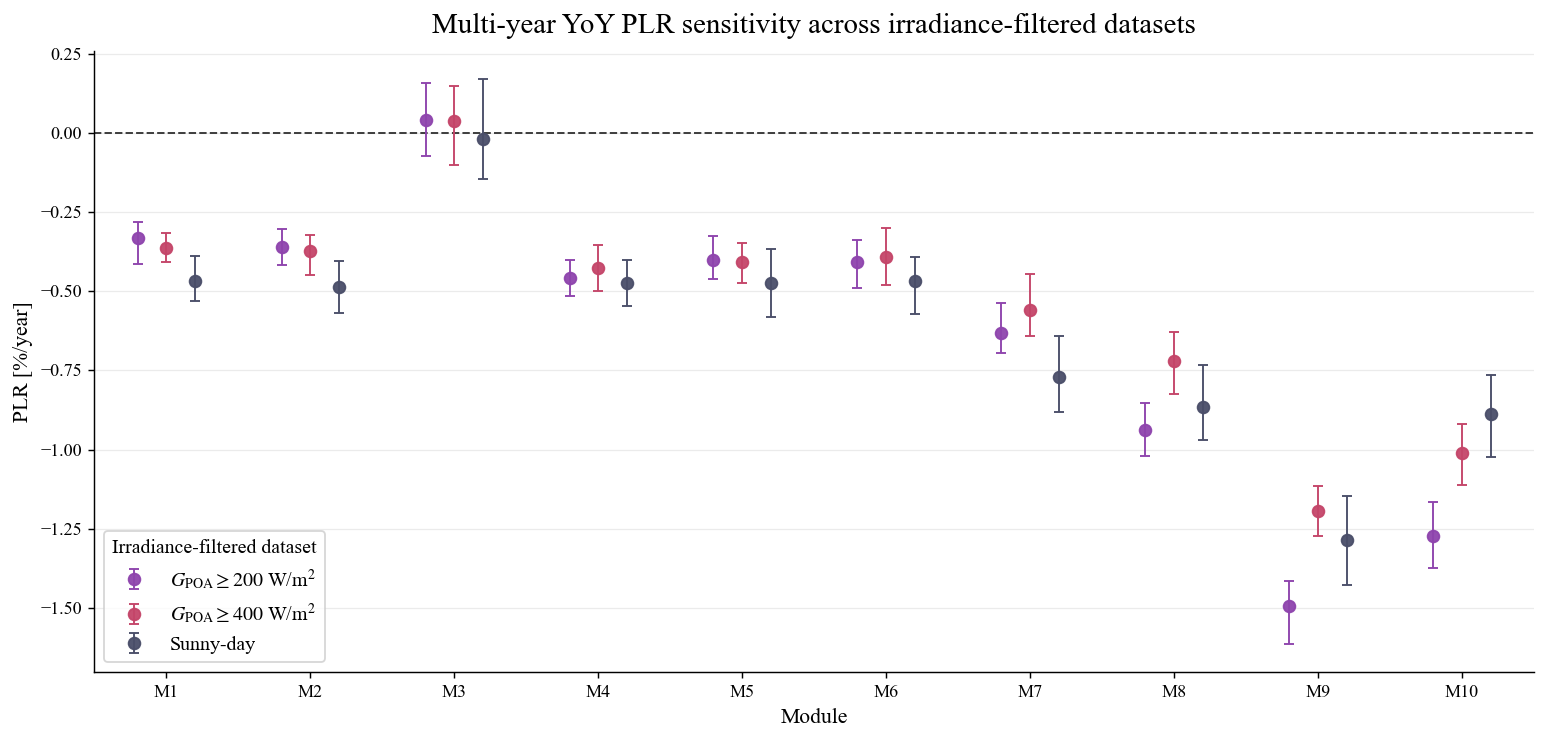

In [18]:
def plot_yoy_irradiance_sensitivity(
    yoy_results,
    save_name="multi_year_yoy_irradiance_filter_sensitivity.png",
):
    dataset_order = ["g200", "g400", "sunny"]

    offsets = {
        "g200": -0.20,
        "g400": 0.00,
        "sunny": 0.20,
    }

    fig, ax = plt.subplots(figsize=(12.0, 5.8))

    for dataset_name in dataset_order:
        sub = (
            yoy_results
            .loc[yoy_results["dataset"] == dataset_name]
            .sort_values("Module_ID")
            .copy()
        )

        x = sub["Module_ID"].to_numpy() + offsets[dataset_name]
        y = sub["PLR_YoY_pct_per_year"].to_numpy()

        yerr_lower = y - sub["PLR_YoY_ci_low_pct_per_year"].to_numpy()
        yerr_upper = sub["PLR_YoY_ci_high_pct_per_year"].to_numpy() - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_lower, yerr_upper],
            fmt="o",
            markersize=6.5,
            color=DATASET_COLORS[dataset_name],
            ecolor=DATASET_COLORS[dataset_name],
            elinewidth=1.1,
            capsize=3,
            capthick=1.1,
            label=DATASET_LABELS[dataset_name],
            alpha=0.95,
            zorder=3,
        )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f"M{i}" for i in range(1, 11)])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Multi-year YoY PLR sensitivity across irradiance-filtered datasets",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Irradiance-filtered dataset",
        loc="lower left",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    save_fig(save_name, fig)
    plt.show()


plot_yoy_irradiance_sensitivity(yoy_results)

## 15. Seasonal overlay plots by module

This diagnostic visualises the seasonal structure of \(PR_\mathrm{DC,25C}\) across years.

For each module, daily \(PR_\mathrm{DC,25C}\) values are plotted against year, with a separate color for each calendar year. This allows the seasonal cycle to be compared across years within the same module.

These plots are not used to calculate PLR directly. They are used to inspect whether particular months or seasons show systematically lower performance and to support interpretation of the multi-year YoY results.

In [19]:
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

YEAR_COLORS = {
    2017: "#4C78A8",
    2018: "#F58518",
    2019: "#54A24B",
    2020: "#B279A2",
    2021: "#E45756",
}

In [34]:
def prepare_binned_daily_seasonality_data(daily_df, bin_days=10):
    """
    Prepare binned seasonal PR_DC,25C data from daily values.

    The binned PR value is calculated as a yield-based ratio of sums,
    not as a simple mean or median.
    """
    df = daily_df.copy()

    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df["Year"] = df[DATE_COL].dt.year
    df["Month"] = df[DATE_COL].dt.month
    df["Day"] = df[DATE_COL].dt.day
    df["DayOfYear"] = df[DATE_COL].dt.dayofyear

    # For faint daily background points
    df["Month_Position"] = (
        df["Month"] + (df["Day"] - 15.5) / 31 * 0.70
    )

    # 10-day seasonal bins
    df["Season_Bin"] = ((df["DayOfYear"] - 1) // bin_days) + 1

    binned = (
        df
        .groupby(["Module_ID", "Type", "Year", "Season_Bin"], as_index=False)
        .agg(
            energy_25C_Wh=("energy_25C_Wh", "sum"),
            reference_energy_Wh=("reference_energy_Wh", "sum"),
            mean_day_of_year=("DayOfYear", "mean"),
            n_days=("Date", "nunique"),
        )
    )

    binned["PR_25C_binned"] = (
        binned["energy_25C_Wh"] / binned["reference_energy_Wh"]
    )

    # Convert day-of-year into approximate month-position for plotting
    binned["Month_Position"] = 1 + (binned["mean_day_of_year"] - 1) / 365.25 * 12

    binned = binned.loc[binned["reference_energy_Wh"] > 0].copy()

    return df, binned


daily_seasonality_g200, binned_seasonality_g200 = prepare_binned_daily_seasonality_data(
    daily_datasets["g200"],
    bin_days=10,
)

In [35]:
def plot_clean_seasonal_profile_one_module(
    daily_seasonality,
    binned_seasonality,
    module_id,
    dataset_name="g200",
    save=True,
    show=True,
    y_limits=None,
):
    """
    Clean seasonal profile plot.

    Faint points show daily PR_DC,25C values.
    Solid lines show yield-weighted 10-day seasonal bins.
    """
    daily_plot = daily_seasonality.loc[
        daily_seasonality["Module_ID"] == module_id
    ].copy()

    binned_plot = binned_seasonality.loc[
        binned_seasonality["Module_ID"] == module_id
    ].copy()

    if daily_plot.empty:
        raise ValueError(f"No seasonality data found for Module {module_id} ({module_type})")

    module_type = MODULE_TYPE_MAP[module_id]

    fig, ax = plt.subplots(figsize=(9.6, 5.4))

    for year in sorted(daily_plot["Year"].unique()):
        daily_year = daily_plot.loc[daily_plot["Year"] == year].copy()
        binned_year = binned_plot.loc[binned_plot["Year"] == year].copy()
        binned_year = binned_year.sort_values("Month_Position")

        color = YEAR_COLORS.get(year, "#666666")

        # Faint daily values
        ax.scatter(
            daily_year["Month_Position"],
            daily_year[MAIN_METRIC],
            s=8,
            alpha=0.16,
            color=color,
            edgecolors="none",
        )

        # Clean weighted seasonal line
        ax.plot(
            binned_year["Month_Position"],
            binned_year["PR_25C_binned"],
            marker="o",
            markersize=4,
            linewidth=1.7,
            alpha=0.95,
            color=color,
            label=str(year),
        )

    ax.set_title(
        rf"Seasonal profile of daily $PR_\mathrm{{DC,25C}}$ for Module {module_id} ({module_type})",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel("Month", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(
        r"$PR_\mathrm{DC,25C}$ [-]",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS)

    if y_limits is not None:
        ax.set_ylim(y_limits)
    else:
        y = daily_plot[MAIN_METRIC].dropna()
        y_low = y.quantile(0.02)
        y_high = y.quantile(0.98)
        y_pad = 0.08 * (y_high - y_low)

        ax.set_ylim(
            max(0, y_low - y_pad),
            y_high + y_pad,
        )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", alpha=0.10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Year",
        loc="best",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save:
        save_fig(
            f"appendix_clean_seasonal_profile_prdc25c_{dataset_name}_module_{module_id:02d}.png",
            fig,
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_10.png


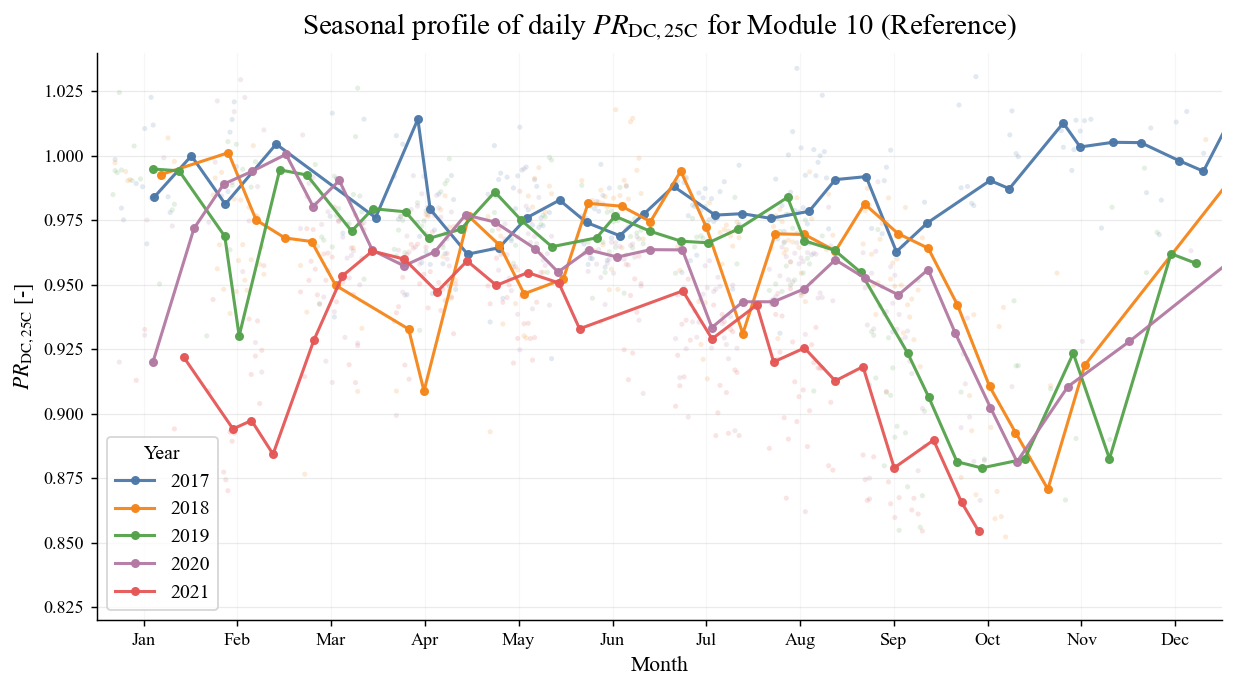

In [36]:
plot_clean_seasonal_profile_one_module(
    daily_seasonality=daily_seasonality_g200,
    binned_seasonality=binned_seasonality_g200,
    module_id=10,
    dataset_name="g200",
    save=True,
    show=True,
    y_limits=(0.82, 1.04),
)

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_01.png


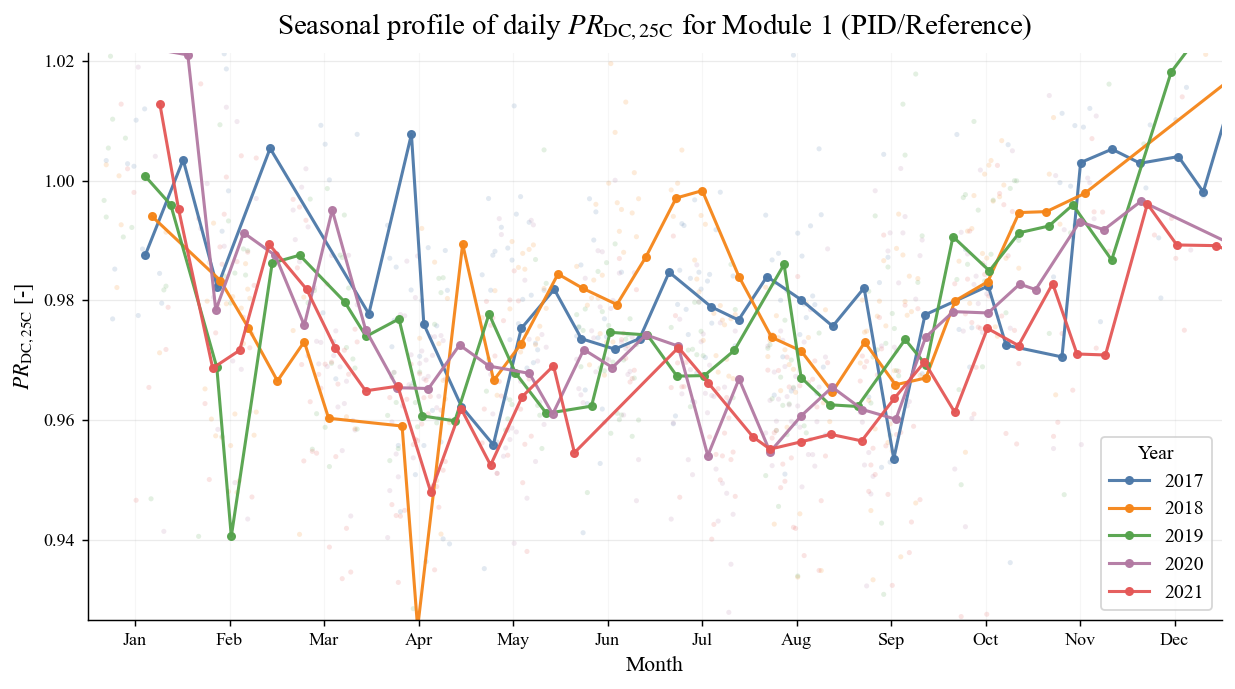

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_02.png


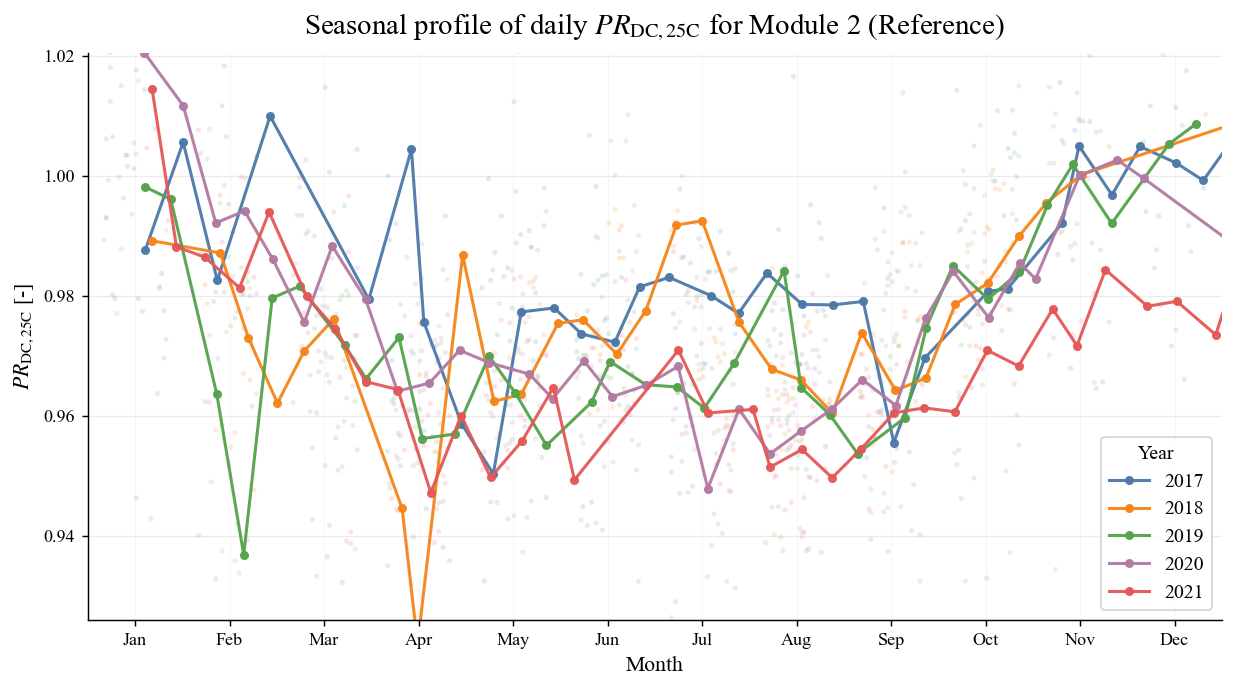

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_03.png


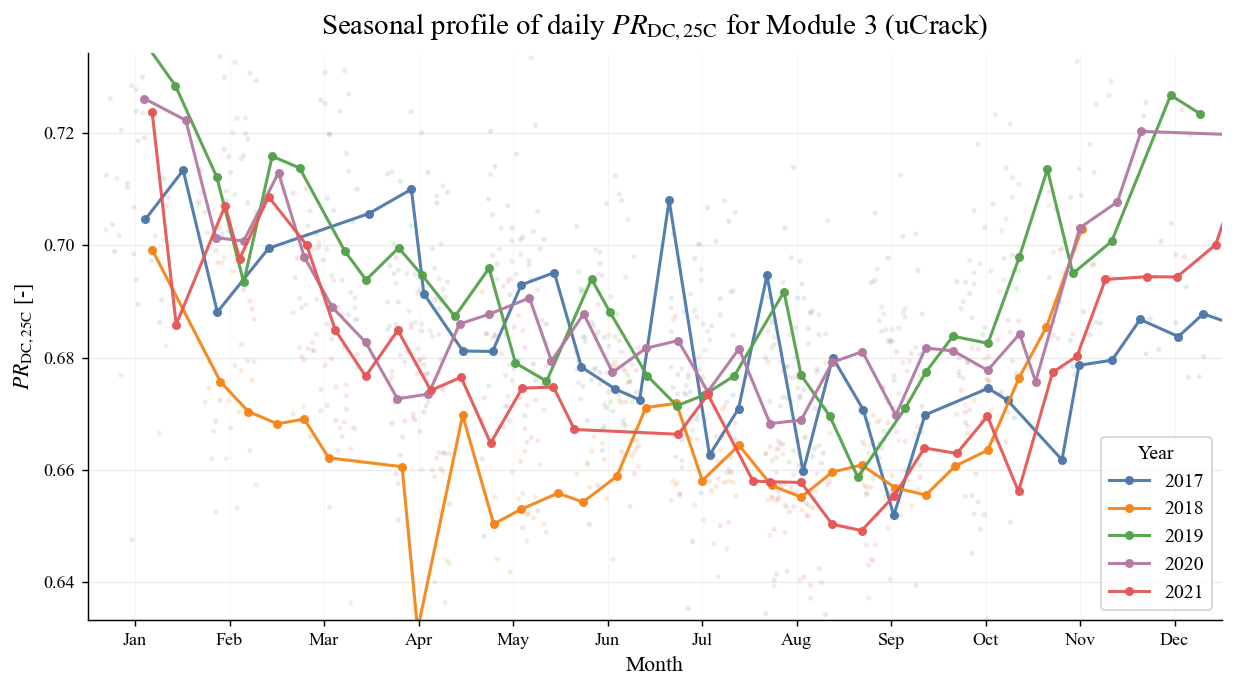

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_04.png


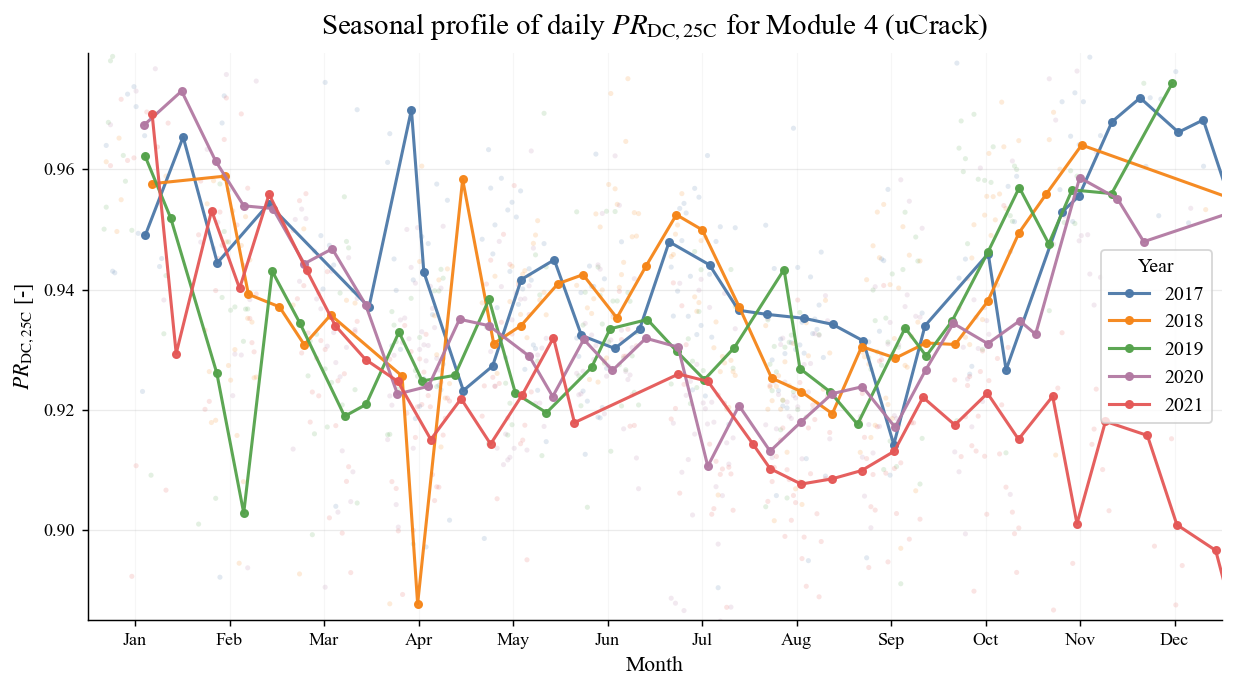

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_05.png


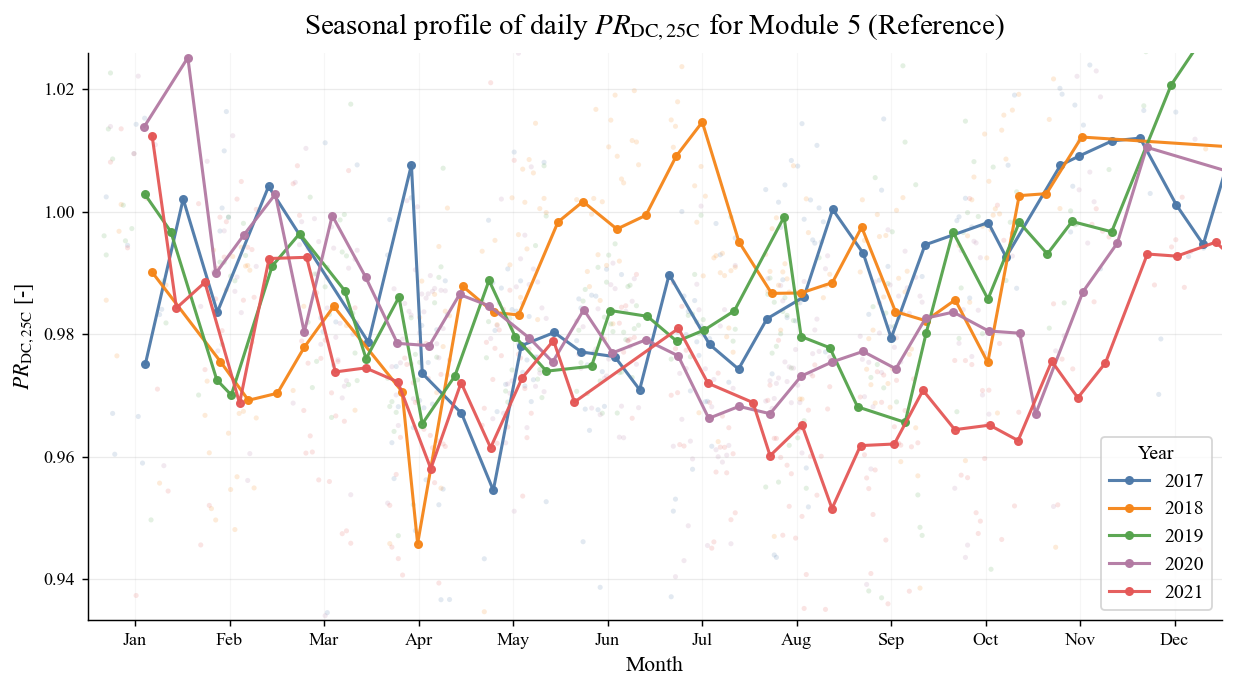

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_06.png


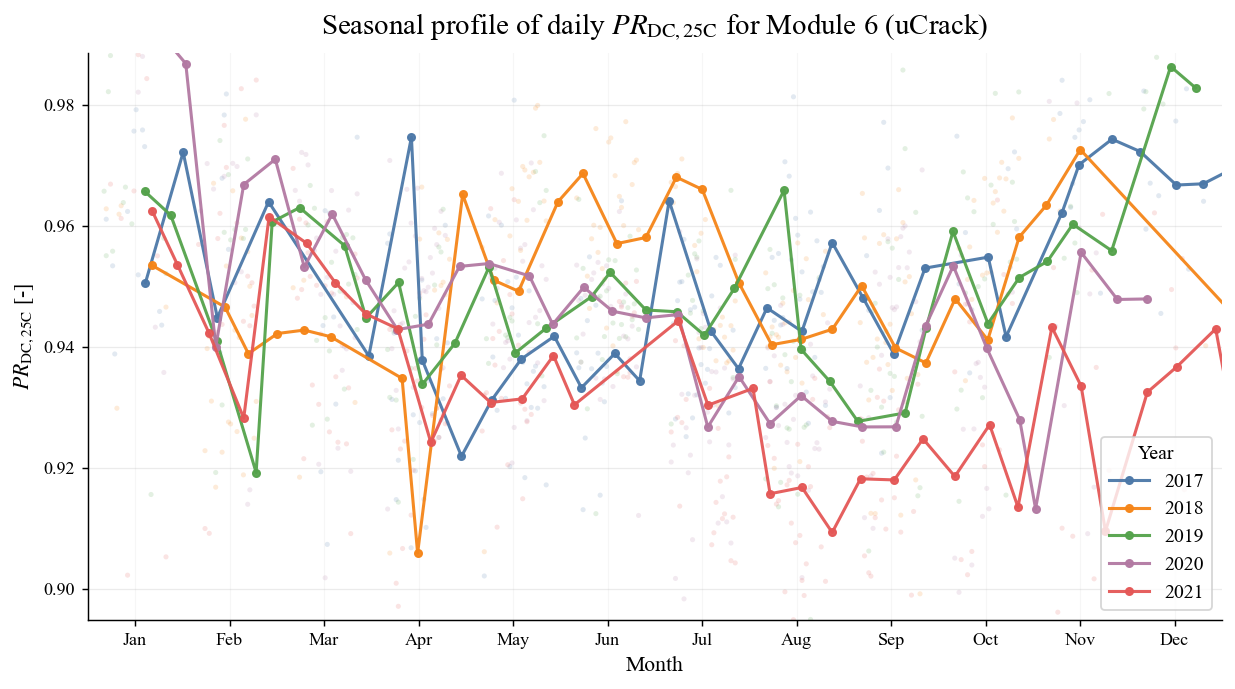

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_07.png


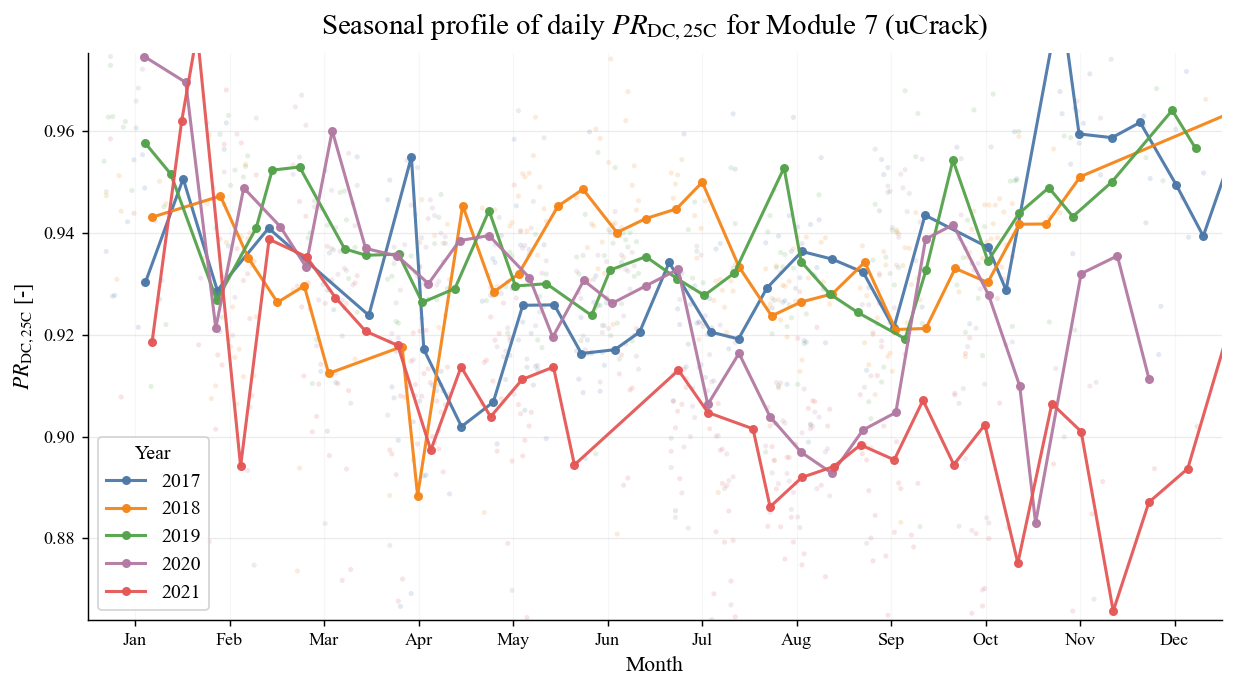

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_08.png


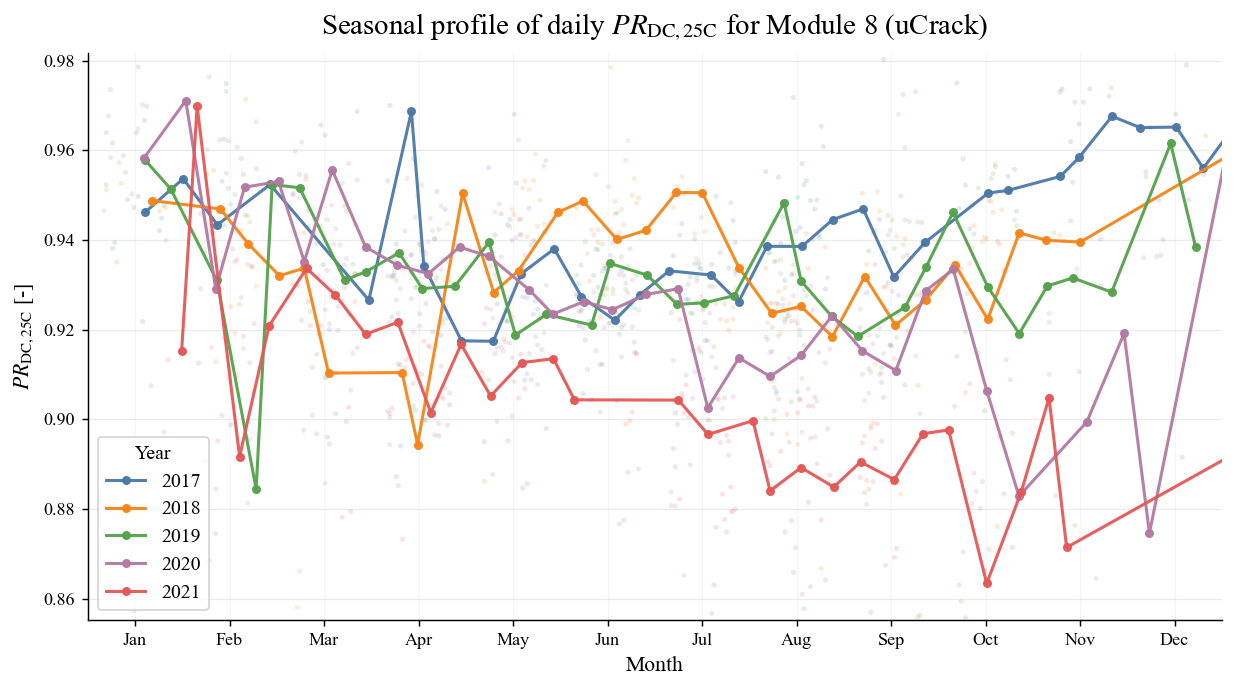

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_clean_seasonal_profile_prdc25c_g200_module_09.png


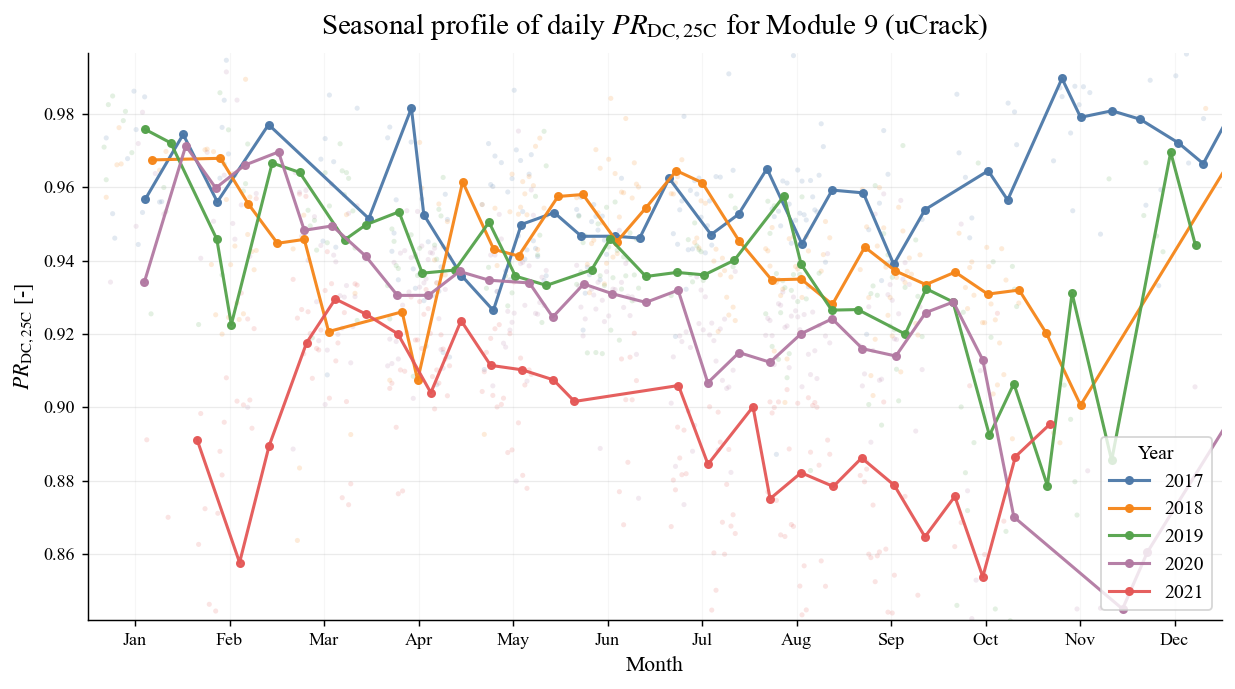

Clean seasonal profile plots exported for all modules.


In [37]:
for module_id in range(1, 10):
    plot_clean_seasonal_profile_one_module(
        daily_seasonality=daily_seasonality_g200,
        binned_seasonality=binned_seasonality_g200,
        module_id=module_id,
        dataset_name="g200",
        save=True,
        show=True,
    )

print("Clean seasonal profile plots exported for all modules.")